# Data Analysis 2 | DATA 5600

## U.S. Pollution Project

### Will Braucher

## Introduction

### Dataset Description

I’m using the EPA’s Air Quality dataset, which tracks daily air pollution levels across the U.S. It includes data like date, city, county, and state, along with readings for pollutants such as ozone, carbon monoxide, sulfur dioxide, and nitrogen dioxide. The main idea behind this dataset is to monitor how air quality changes across different regions and time periods, which makes it really useful for pollution patterns and how they might connect to things like policy, weather, or area. I pulled it off of Kaggle though not the EPA website since it is already cleaned.

so i dont' forget later like last time: https://www.kaggle.com/datasets/guslovesmath/us-pollution-data-200-to-2022?resource=download

### Purpose of the Analysis

The main goal of this project is to look at overall air pollution levels in the U.S. and see how the main pollutants relate to each other. By focusing on the mean values of CO, $NO_2$, $SO_2$, and $O_3$, I want to get a better idea of general air quality trends and which pollutants tend to be higher or lower on average. Ozone is a key pollutant near the ground that can harm human health and the environment, so understanding what drives its levels is especially important. This analysis should help show what the data says about pollution patterns and where air quality might be more of a concern.

### Response and Predictor Variables

For this analysis, the response variable is $O_3$ Mean, and the predictor variables are CO Mean, $NO_2$ Mean, and $SO_2$ Mean, and my categorical predictor variable will be reigon since I want to see how these main pollutants relate to ozone levels.

### Research Question

Can ozone levels in U.S. locations be predicted by other pollutants and do certain areas tend to have higher ozone levels than others?

## Data Cleaning and Exploratory Data Analysis (EDA)

### Initial Look at the Data

I started by previewing the dataset to understand its structure and identify any immediate issues. This included checking the first few rows, verifying data types, and viewing basic summary statistics.

In [167]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import warnings
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.linear_model import LinearRegression

from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings('ignore')

df = pd.read_csv('pollution_2000_2023.csv')
df.head()

,Unnamed: 0,Date,Address,State,County,City,O3 Mean,O3 1st Max Value,O3 1st Max Hour,O3 AQI,...,CO 1st Max Hour,CO AQI,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI
0,0,2000-01-01,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.019765,0.040,10,37,...,23,25.0,3.000000,9.0,21,13.0,19.041667,49.0,19,46
1,1,2000-01-02,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,0.032,10,30,...,0,26.0,1.958333,3.0,22,4.0,22.958333,36.0,19,34
2,2,2000-01-03,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009353,0.016,9,15,...,8,28.0,5.250000,11.0,19,16.0,38.125000,51.0,8,48
3,3,2000-01-04,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,0.033,9,31,...,23,34.0,7.083333,16.0,8,23.0,40.260870,74.0,8,72
4,4,2000-01-05,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.007353,0.012,9,11,...,2,42.0,8.708333,15.0,7,21.0,48.450000,61.0,22,58


The data looks good overall. There are a lot of rows, and I’ll be cutting down the number of columns since I only need a few for my analysis. The Unnamed: 0 column will also need to be dropped. Everything else looks reasonable, though the daily measurements create a time series issue with potential correlation between days that will need to be addressed later.

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665414 entries, 0 to 665413
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         665414 non-null  int64  
 1   Date               665414 non-null  object 
 2   Address            665414 non-null  object 
 3   State              665414 non-null  object 
 4   County             665414 non-null  object 
 5   City               665414 non-null  object 
 6   O3 Mean            665414 non-null  float64
 7   O3 1st Max Value   665414 non-null  float64
 8   O3 1st Max Hour    665414 non-null  int64  
 9   O3 AQI             665414 non-null  int64  
 10  CO Mean            665414 non-null  float64
 11  CO 1st Max Value   665414 non-null  float64
 12  CO 1st Max Hour    665414 non-null  int64  
 13  CO AQI             665414 non-null  float64
 14  SO2 Mean           665414 non-null  float64
 15  SO2 1st Max Value  665414 non-null  float64
 16  SO

In [170]:
df.describe()

,Unnamed: 0,O3 Mean,O3 1st Max Value,O3 1st Max Hour,O3 AQI,CO Mean,CO 1st Max Value,CO 1st Max Hour,CO AQI,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI
count,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000
mean,332706.500000,0.028605,0.038980,10.766409,39.137872,0.329459,0.465604,5.922553,5.247399,1.428759,3.931057,8.867280,5.154743,11.510561,23.253519,11.588897,21.766209
std,192088.620348,0.012151,0.014912,3.297315,22.253413,0.275725,0.434542,7.719537,5.010467,2.410071,7.700799,6.776779,10.371465,8.957527,15.264335,7.888301,14.447780
min,0.000000,-0.000706,0.000000,7.000000,0.000000,-0.437500,-0.400000,0.000000,0.000000,-2.508333,-2.300000,0.000000,0.000000,-4.629167,-4.400000,0.000000,0.000000
25%,166353.250000,0.019824,0.029000,9.000000,27.000000,0.175000,0.200000,0.000000,2.000000,0.173913,0.600000,3.000000,0.000000,4.860870,11.000000,5.000000,10.000000
50%,332706.500000,0.028353,0.038000,10.000000,35.000000,0.258333,0.300000,1.000000,3.000000,0.604167,1.400000,8.000000,1.000000,9.304348,21.000000,9.000000,20.000000
75%,499059.750000,0.036882,0.048000,11.000000,44.000000,0.408696,0.600000,9.000000,7.000000,1.604545,4.000000,13.000000,6.000000,15.958333,33.000000,20.000000,31.000000
max,665413.000000,0.107353,0.140000,23.000000,237.000000,7.508333,15.500000,23.000000,201.000000,321.625000,351.000000,23.000000,200.000000,140.650000,371.700000,23.000000,153.000000


Looking at the summary statistics, the numbers generally make sense. The dataset has a lot of rows, so we’ll likely need to do a group-by to summarize site-level measurements and make the analysis more manageable. Most values for O3, CO, and NO2 look reasonable, but SO2 Mean has a very high max and some negative minimums, which will need to be looked into further. Overall, the data looks usable, but the negatives and extreme SO2 values are the main issues and will need to be cleaned.

### Cleaning the Data

In [173]:
dropping_columns = ['Unnamed: 0', 'O3 1st Max Value', 'O3 1st Max Hour', 'O3 AQI',
    'CO 1st Max Value', 'CO 1st Max Hour', 'CO AQI',
    'SO2 1st Max Value', 'SO2 1st Max Hour', 'SO2 AQI',
    'NO2 1st Max Value', 'NO2 1st Max Hour', 'NO2 AQI']

df = df.drop(columns=dropping_columns)

mean_cols = ['O3 Mean', 'CO Mean', 'SO2 Mean', 'NO2 Mean']

df[mean_cols] = np.where(df[mean_cols] < 0, 0, df[mean_cols])

df.head()

,Date,Address,State,County,City,O3 Mean,CO Mean,SO2 Mean,NO2 Mean
0,2000-01-01,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.019765,0.878947,3.000000,19.041667
1,2000-01-02,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,1.066667,1.958333,22.958333
2,2000-01-03,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009353,1.762500,5.250000,38.125000
3,2000-01-04,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,1.829167,7.083333,40.260870
4,2000-01-05,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.007353,2.700000,8.708333,48.450000


I dropped all the “1st Max Value,” “1st Max Hour,” and “AQI” columns for each pollutant, along with the “Unnamed: 0” column. The “Unnamed: 0” column was just an extra index, so it wasn’t needed. The AQI and Max columns were removed because I’m focusing on the mean levels of pollutants, not the peaks or AQI scores, which keeps the dataset cleaner and easier to work with. I also replaced any negative values in the mean pollutant columns with 0 because negative concentrations don’t make sense. Pollution measurements are based on actual sensor readings, and it’s impossible to have less than zero. These negatives are probably just measurement or recording errors from how the EPA collected the data, so fixing them keeps the dataset realistic and reliable for analysis.

In [175]:
import pandas as pd

 

def summarize_by_group(df: pd.DataFrame, group_cols, constant_cols="auto"):

    """

    Group by one or more categorical columns, take means of numeric columns,

    and carry along variables that are constant within each group.

 

    Parameters

    ----------

    df : pd.DataFrame

        Input DataFrame

    group_cols : str | list[str]

        Column name(s) to group by (can be one or multiple)

    constant_cols : "auto" | list[str]

        - "auto": detect columns that have the same value within each group

        - list of column names: treat these as constant (use first) regardless

 

    Returns

    -------

    pd.DataFrame

        One row per group, with numeric means and chosen constant columns.

    """

    # Ensure group_cols is a list

    if isinstance(group_cols, str):

        group_cols = [group_cols]

 

    # numeric columns to average

    num_cols = df.select_dtypes(include="number").columns.difference(group_cols).tolist()

 

    # constant columns: either auto-detect or use provided list

    if constant_cols == "auto":

        candidate_cols = df.columns.difference(group_cols + num_cols)

        const_cols = []

        for col in candidate_cols:

            nunique_per_group = df.groupby(group_cols)[col].nunique(dropna=False)

            if (nunique_per_group <= 1).all():

                const_cols.append(col)

    else:

        const_cols = list(constant_cols)

 

    # build aggregation dictionary

    agg_dict = {c: "mean" for c in num_cols}

    agg_dict.update({c: "first" for c in const_cols})

 

    # perform aggregation

    out = df.groupby(group_cols, as_index=False).agg(agg_dict)

    return out

In [176]:
pollution_df = summarize_by_group(df, ['State', 'County', 'Address'])
pollution_df

,State,County,Address,CO Mean,NO2 Mean,O3 Mean,SO2 Mean
0,Alabama,Jefferson,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",0.243282,8.856462,0.027123,0.866068
1,Alaska,Fairbanks North Star,809 Pioneer Road,0.374673,11.237066,0.015281,5.635377
2,Arizona,Maricopa,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,0.523678,21.091539,0.028326,1.328253
3,Arizona,Maricopa,2857 N MILLER RD-S SCOTTSDALE STN,0.584245,22.619903,0.020987,1.582203
4,Arizona,Maricopa,4530 N 17TH AVENUE,0.495108,16.635169,0.030383,1.328549
...,...,...,...,...,...,...,...
216,Wisconsin,Milwaukee,"UWM NORTH CAMPUS, 2114 E KENWOOD BLVD",0.241131,13.315972,0.033064,3.237736
217,Wyoming,Fremont,"90 GAS HILL ROAD, RIVERTON, WY",0.000000,1.545645,0.035018,0.202336
218,Wyoming,Laramie,NCore - North Cheyenne Soccer Complex,0.088853,3.603367,0.039222,0.342664
219,Wyoming,Sweetwater,Tata Gaseous,0.373589,4.472316,0.034708,0.504075


I used the summarize_by_group function to clean up the pollution dataset because the original data had daily measurements for each site, which made it a time series and could cause correlation between days. By grouping by state, county, and site, this just keeps the already-averaged pollutant values while holding onto constant info like the location identifiers. Now each row represents a summarized site-level measurement, avoids the time series issue Dr. Z talked about, and makes the data easier to work with for the regression.

In [178]:
region_map = {
    # Northeast
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast',
    'New Hampshire': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast',
    'New Jersey': 'Northeast', 'New York': 'Northeast', 'Pennsylvania': 'Northeast',
    # Midwest
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Iowa': 'Midwest', 'Kansas': 'Midwest',
    'Michigan': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest', 'Nebraska': 'Midwest',
    'North Dakota': 'Midwest', 'Ohio': 'Midwest', 'South Dakota': 'Midwest', 'Wisconsin': 'Midwest',
    # South
    'Alabama': 'South', 'Arkansas': 'South', 'Delaware': 'South', 'District Of Columbia': 'South',
    'Florida': 'South', 'Georgia': 'South', 'Kentucky': 'South', 'Louisiana': 'South', 'Maryland': 'South',
    'Mississippi': 'South', 'North Carolina': 'South', 'Oklahoma': 'South', 'South Carolina': 'South',
    'Tennessee': 'South', 'Texas': 'South', 'Virginia': 'South', 'West Virginia': 'South',
    # West
    'Alaska': 'West', 'Arizona': 'West', 'California': 'West', 'Colorado': 'West', 'Hawaii': 'West',
    'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West', 'New Mexico': 'West', 'Oregon': 'West',
    'Utah': 'West', 'Washington': 'West', 'Wyoming': 'West'
}

pollution_df['Region'] = pollution_df['State'].map(region_map)
pollution_df.head()

,State,County,Address,CO Mean,NO2 Mean,O3 Mean,SO2 Mean,Region
0,Alabama,Jefferson,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",0.243282,8.856462,0.027123,0.866068,South
1,Alaska,Fairbanks North Star,809 Pioneer Road,0.374673,11.237066,0.015281,5.635377,West
2,Arizona,Maricopa,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,0.523678,21.091539,0.028326,1.328253,West
3,Arizona,Maricopa,2857 N MILLER RD-S SCOTTSDALE STN,0.584245,22.619903,0.020987,1.582203,West
4,Arizona,Maricopa,4530 N 17TH AVENUE,0.495108,16.635169,0.030383,1.328549,West


I created a new “Region” column to group states into broader geographic categories (West, South, Midwest, and Northeast). This helps capture large-scale regional trends in pollution that individual states might not show on their own. It also makes the model more balanced since some states have very few observations, while grouping them by region keeps the analysis consistent and easier to interpret. It also fulfills my categorical varaible I needed to have 3 continous and 1 categorical predictors.

### Summary of Cleaned Data

In [181]:
pollution_df.describe()

,CO Mean,NO2 Mean,O3 Mean,SO2 Mean
count,221.000000,221.000000,221.000000,221.000000
mean,0.330022,11.240203,0.029514,1.765460
std,0.203448,6.477988,0.005266,1.833884
min,0.000000,0.680757,0.013864,0.048319
25%,0.205748,6.594280,0.026464,0.487694
50%,0.281839,10.808218,0.029298,0.975870
75%,0.403596,14.136640,0.032693,2.535025
max,1.232222,36.978651,0.049525,11.300478


The summary statistics look reasonable overall. The minimum values make sense now that the negative values were replaced with 0, and the averages for each pollutant fall within typical U.S. air quality ranges. SO2 still has a fairly large outlier with a max value of around 11, and NO2 Mean has a max of 37 which is also a moderate outlier. So I’ll keep an eye on that when checking assumptions. Otherwise, the data looks clean and ready for the next steps!

### Histograms of continuous variables

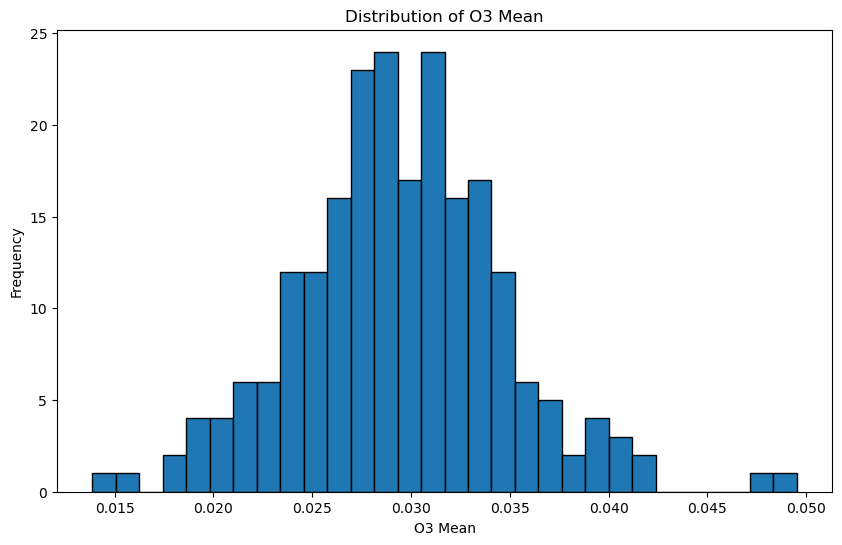

In [184]:
# Histogram for O3
fig = plt.figure(figsize=(10, 6))
plt.hist(pollution_df['O3 Mean'], bins=30, edgecolor='black')
plt.xlabel("O3 Mean")
plt.ylabel("Frequency")
plt.title("Distribution of O3 Mean")
plt.show()

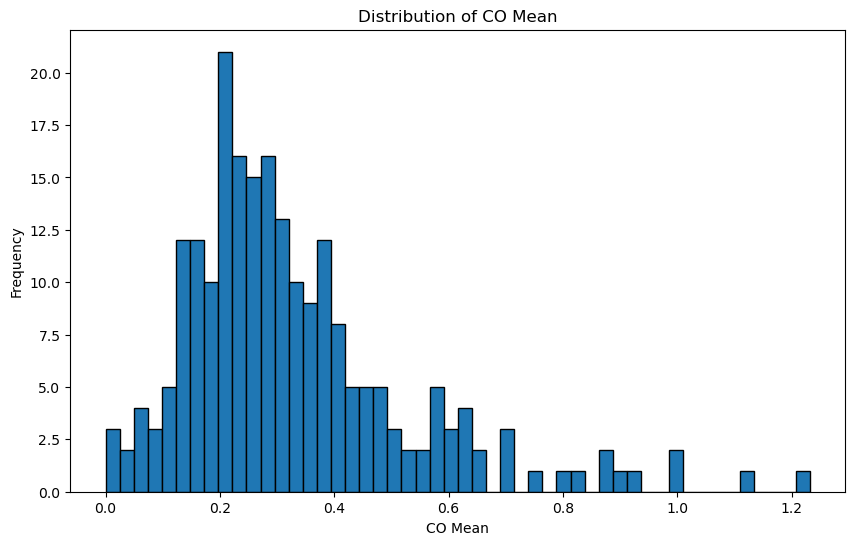

In [185]:
# Histogram for CO pollutant
fig = plt.figure(figsize=(10, 6))
plt.hist(pollution_df['CO Mean'], bins=50, edgecolor='black')
plt.xlabel("CO Mean")
plt.ylabel("Frequency")
plt.title("Distribution of CO Mean")
plt.show()

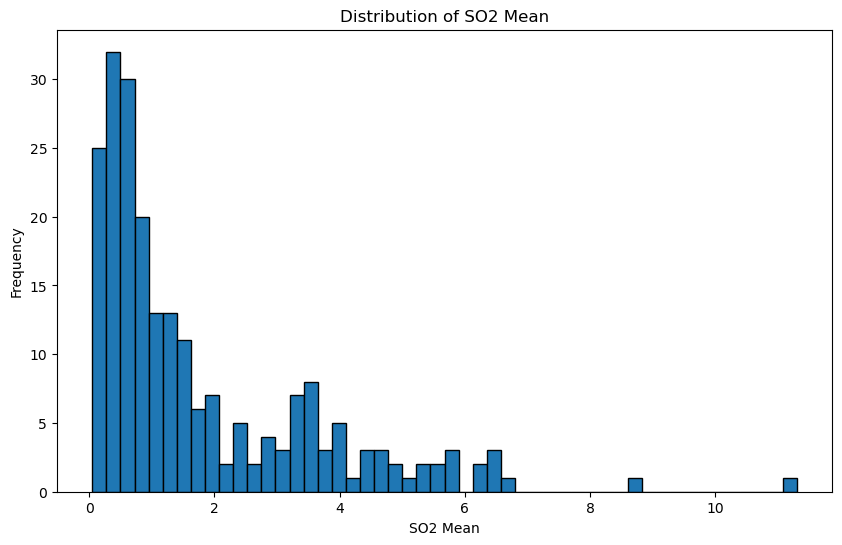

In [186]:
# Histogram for SO2 pollutant
fig = plt.figure(figsize=(10, 6))
plt.hist(pollution_df['SO2 Mean'], bins=50, edgecolor='black')
plt.xlabel("SO2 Mean")
plt.ylabel("Frequency")
plt.title("Distribution of SO2 Mean")
plt.show()

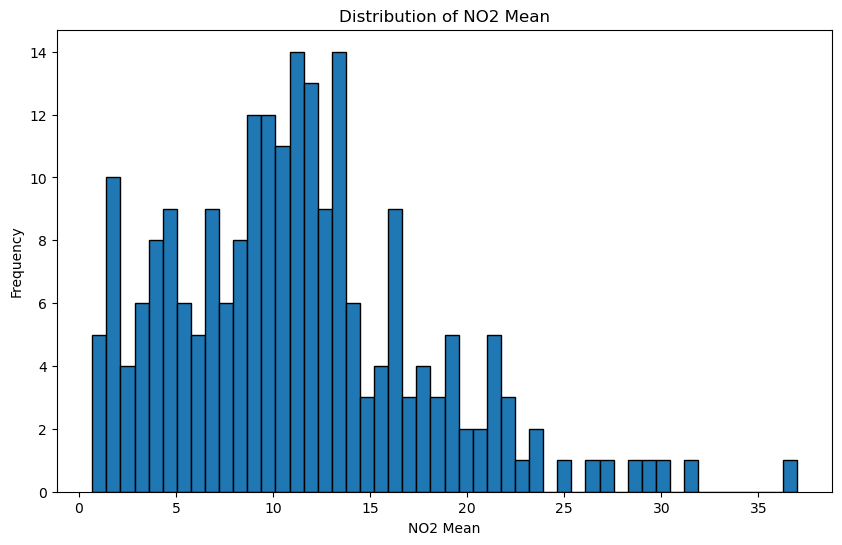

In [187]:
# Histogram for NO2 pollutant
fig = plt.figure(figsize=(10, 6))
plt.hist(pollution_df['NO2 Mean'], bins=50, edgecolor='black')
plt.xlabel("NO2 Mean")
plt.ylabel("Frequency")
plt.title("Distribution of NO2 Mean")
plt.show()

### Scatterplot Matrix

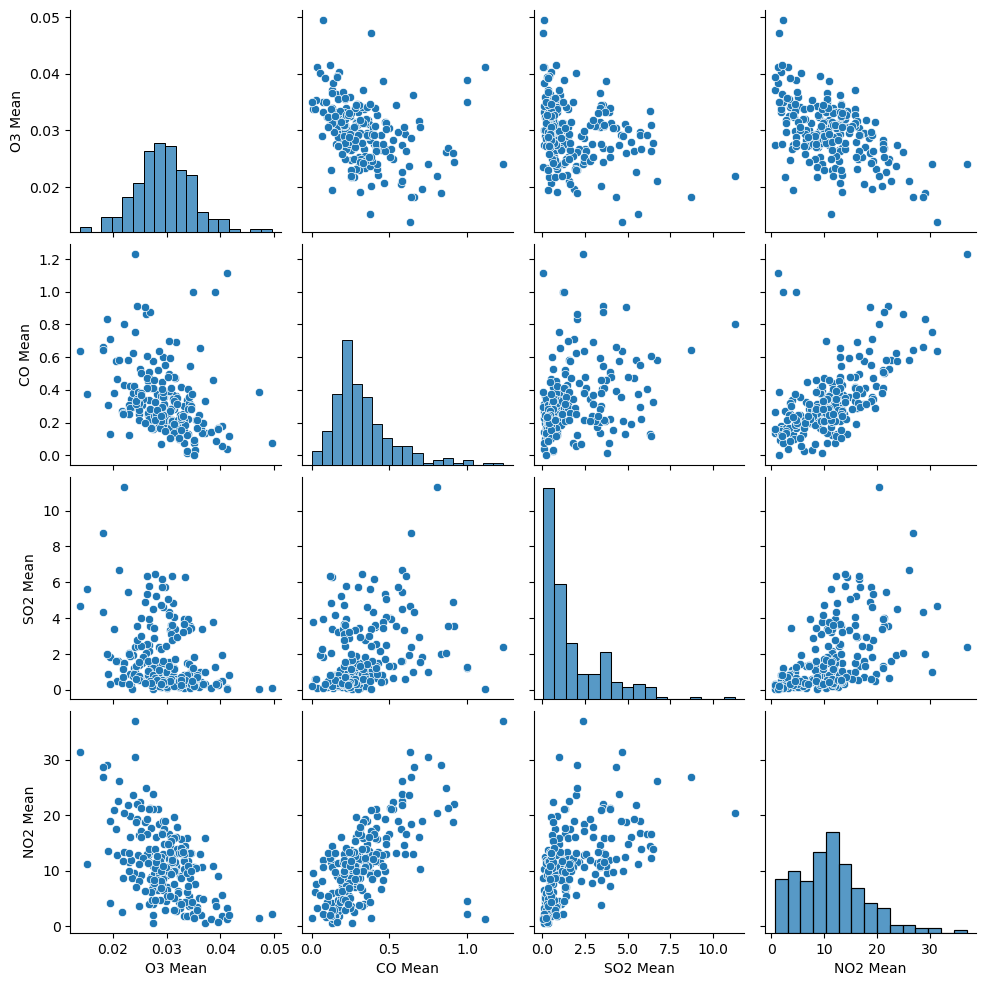

In [189]:
sns.pairplot(pollution_df[['O3 Mean', 'CO Mean', 'SO2 Mean', 'NO2 Mean']])

Looking at the scatterplot matrix, O3 Mean is the most evenly spread out, while CO Mean, SO2 Mean, and NO2 Mean are all a bit right-skewed. CO Mean and NO2 Mean seem to move together moderately, though not perfectly. SO2 Mean is more all over the place with the other pollutants, so the relationships there aren’t very strong. O3 Mean looks like it has a negative relationship with the others, especially NO2 Mean, where higher O3 tends to show up with lower NO2. You can see that some pollutants, like CO and NO2, kind of follow each other, while others, like SO2 and O3, don’t really line up.

### Correlation Matrix

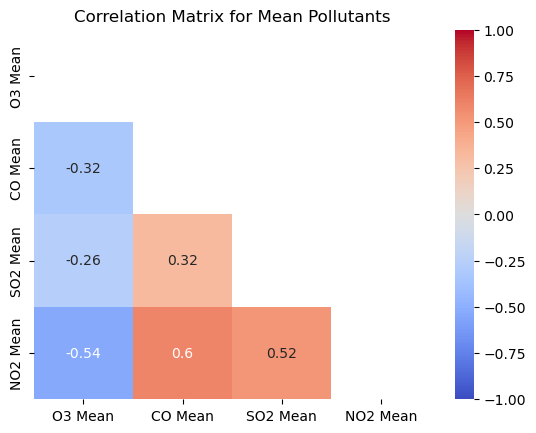

In [192]:
corr_matrix = pollution_df[['O3 Mean', 'CO Mean', 'SO2 Mean', 'NO2 Mean']].corr()

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True,
            vmin=-1,
            vmax=1,
            mask=np.triu(corr_matrix))
plt.title("Correlation Matrix for Mean Pollutants")
plt.show()

Looking at the correlations, CO Mean and NO2 Mean have the strongest link at around 0.6, which is moderately strong. That’s something to keep an eye on for multicollinearity, but it’s still under the usual 0.8 cutoff, so it should be fine. SO2 Mean doesn’t really correlate much with the other predictors, so it’s unlikely to cause any problems. O3 Mean actually has negative correlations with all the other pollutants, so it’s pretty independent. The only one to watch is CO and NO2, but otherwise multicollinearity doesn’t look like a big issu looking at our numbers.

### Number of rows in each category of a categorical variable

In [195]:
pollution_df['Region'].value_counts()

Region
West         82
South        60
Northeast    45
Midwest      34
Name: count, dtype: int64

Looking at the number of rows per region, there’s a clear difference in representation. The West has the most observations at 82, while the Midwest only has 34. This shows that some regions are represented a lot more than others, which could affect the analysis if I compared them directly. It also supports using aggregated site-level means instead of daily data to keep things consistent across regions.

### Boxplots of categorical variables against the response variable

<Figure size 1200x600 with 0 Axes>

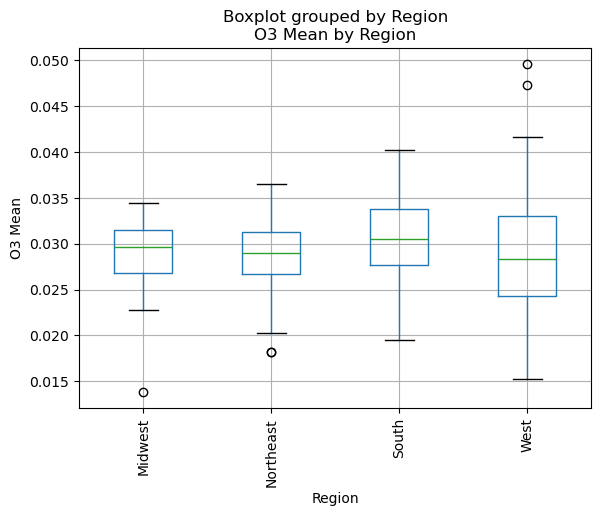

In [198]:
fig = plt.figure(figsize=(12, 6))
pollution_df.boxplot(column='O3 Mean', by='Region')
plt.title("O3 Mean by Region")
plt.xlabel("Region")
plt.ylabel("O3 Mean")
plt.xticks(rotation=90)
plt.show()


Most regions have pretty similar median O3 Mean values, with the medians sitting fairly close across the country. The West and Northeast show a lot more spread, meaning ozone levels tend to fluctuate more there. Overall, the medians are pretty consistent, even though a few regions vary more. There aren’t many outliers, but the West stands out with a couple of really high values, and the Midwest has one that’s noticeably low.

### Interaction Plots

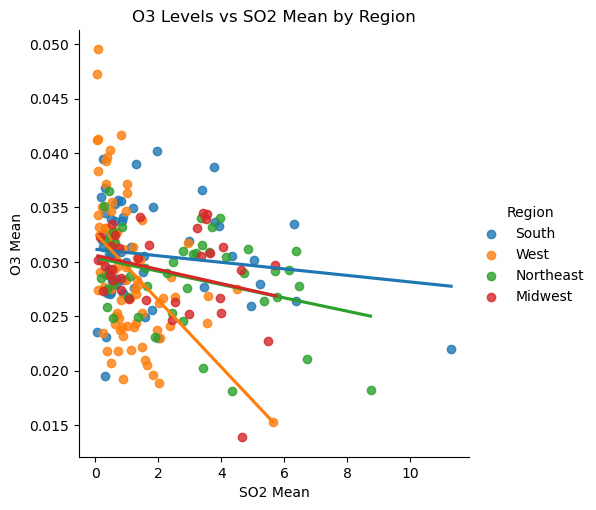

In [201]:
sns.lmplot(
    data=pollution_df,
    x='SO2 Mean',
    y='O3 Mean',
    hue='Region',
    ci=None, 
)

plt.xlabel('SO2 Mean')
plt.ylabel('O3 Mean')
plt.title('O3 Levels vs SO2 Mean by Region')
plt.show()


This plot looks at SO2 Mean versus O3 Mean by region. The pattern here is less clear. Some regions show a slight drop in ozone with higher SO2, but it is not a strong or consistent trend. Most points are clustered near zero for SO2, especially in the Northeast and Midwest, showing that SO2 levels are usually low and do not add much predictive power for ozone.

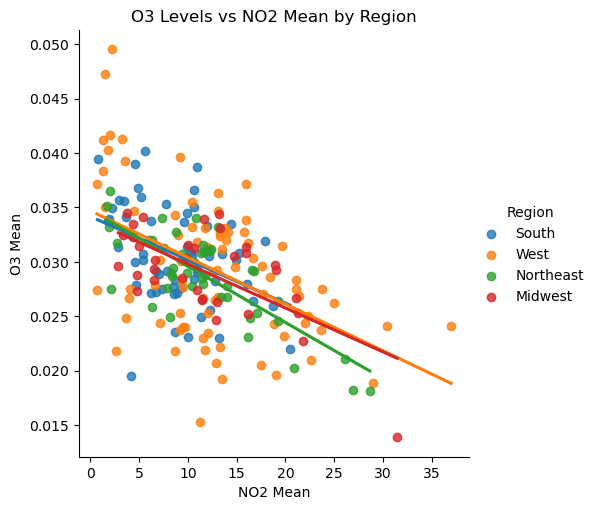

In [203]:
sns.lmplot(
    data=pollution_df,
    x='NO2 Mean',
    y='O3 Mean',
    hue='Region',
    ci=None
)

plt.xlabel('NO2 Mean')
plt.ylabel('O3 Mean')
plt.title('O3 Levels vs NO2 Mean by Region')
plt.show()

The scatter plot shows a noticeable negative relationship between NO2 Mean and O3 Mean across the U.S. As average NO₂ goes up, ozone tends to go down, and this pattern is pretty consistent across all regions. The points are somewhat spread out, which tells me that while NO₂ clearly matters, it does not capture all the variation in ozone.

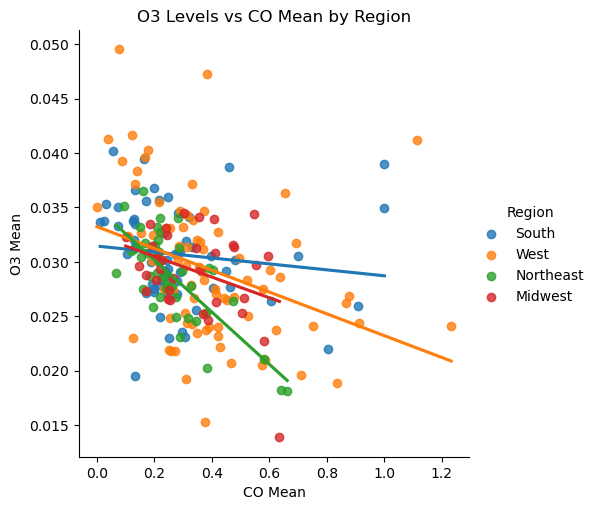

In [205]:
sns.lmplot(
    data=pollution_df,
    x='CO Mean',
    y='O3 Mean',
    hue='Region',
    ci=None
)

plt.xlabel('CO Mean')
plt.ylabel('O3 Mean')
plt.title('O3 Levels vs CO Mean by Region')
plt.show()


This plot shows CO Mean against O3 Mean by region. Like SO₂, the relationship is weak. There is a slight negative trend in some regions, with higher CO linked to lower ozone, particularly in the West and Northeast. Most CO values are near zero outside the West, so the effect is limited. The regional lines hint that CO might influence ozone differently across areas, but compared to NO2, its role is smaller.

## Regression Model and Assumptions¶

### Fitting the Linear Regression

In [209]:
import pandas as pd
import statsmodels.api as sm

# Create dummy variables for Region, dropping Midwest as the baseline
region_dummy = pd.get_dummies(pollution_df, columns=['Region'], drop_first=False)

# Drop 'Region_Midwest' to make it the baseline
region_dummy = region_dummy.drop(columns=['Region_Midwest'])

# Convert remaining dummy columns to int
region_cols = ['Region_Northeast', 'Region_South', 'Region_West']
region_dummy[region_cols] = region_dummy[region_cols].astype(int)

# Define predictors (excluding Midwest baseline)
X = region_dummy[['CO Mean', 'NO2 Mean', 'SO2 Mean'] + region_cols]
y = region_dummy['O3 Mean']

# Add constant for intercept
x_full = sm.add_constant(X)

# Fit model
mod_full = sm.OLS(y, x_full)
res_full = mod_full.fit()

# Add residuals and fitted values to the original dataframe
pollution_df['residuals'] = res_full.resid
pollution_df['fittedvalues'] = res_full.fittedvalues

# Display summary
res_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                O3 Mean   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     15.07
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.29e-14
Time:                        20:19:40   Log-Likelihood:                 885.33
No. Observations:                 221   AIC:                            -1757.
Df Residuals:                     214   BIC:                            -1733.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0343      0.001     35.068      0.000       0.032       0.036
CO Mean             -0.0009      0.002     -0.455      0.650      -0.005       0.003
NO2 Mean            -0.0005   6.69e-05     -6.785      0.000      -0.001      -0.000
SO2 Mean             0.0002      0.000      0.937      0.350      -0.000       0.001
Region_Northeast    -0.0006      0.001     -0.577      0.565      -0.003       0.001
Region_South         0.0003      0.001      0.322      0.748      -0.002       0.002
Region_West          0.0009      0.001      0.907      0.365      -0.001       0.003
==============================================================================
Omnibus:                        6.534   Durbin-Watson:                   1.341
Prob(Omnibus):                  0.038   Jarque-Bera (JB):                9.008
Skew:                          -0.169   Prob(JB):                       0.0111
Kurtosis:                       3.930   Cond. No.                         86.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### (L) X vs Y linear (One diagonostic tool)

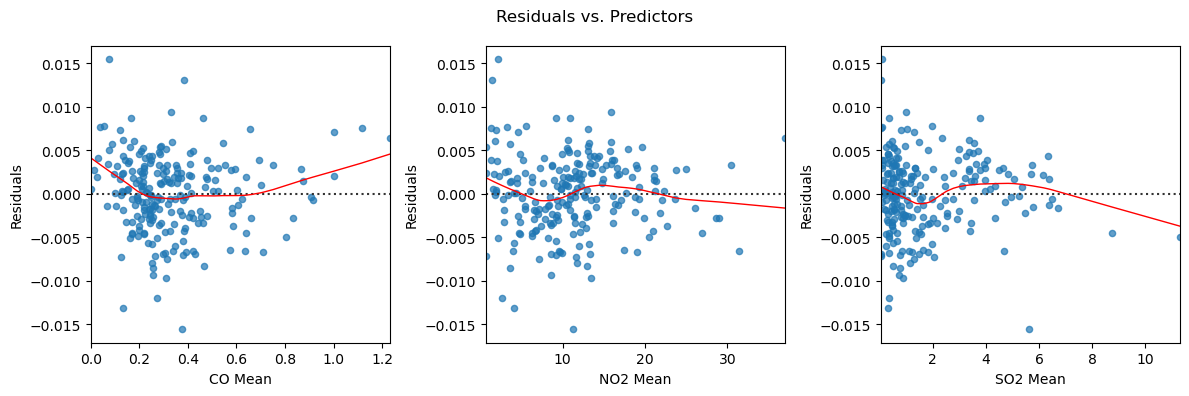

In [211]:
# residual vs predictor plots
def res_vs_pred(variable, ax):
    sns.residplot(
        x=pollution_df[variable],
        y=pollution_df['residuals'],
        lowess=True,
        scatter_kws={'s': 20, 'alpha': 0.7},
        line_kws={'color': 'red', 'lw': 1},
        ax=ax
    )
    ax.set_xlabel(variable)
    ax.set_ylabel("Residuals")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plt.suptitle("Residuals vs. Predictors")

res_vs_pred("CO Mean", axes[0])
res_vs_pred("NO2 Mean", axes[1])
res_vs_pred("SO2 Mean", axes[2])

fig.tight_layout()
plt.show()

Based on the residuals versus predictor plots, the linearity assumption seems most off for CO Mean, which shows a clear U-shaped pattern. SO2 Mean looks a bit different since it has more of an upside-down horn shape where the residuals start high, narrow in the middle, and then drop at higher values. That still points to some non-linearity but not quite the same as with CO. The NO2 Mean plot doesn’t show a strong pattern. There’s a small dip and rise, but overall, the residuals look more evenly spread, meaning the relationship there seems mostly fine. However, I would say that we violate the linearity assumption overall, so we will need to do some transformations!

### (I) Are the residuals independent?¶

The residuals are likely independent. The original dataset had daily measurements for each site, which would create a time-series effect and violate independence. To address this, I aggregated the data by state, county, and site, so each observation now represents a summarized site-level measurement instead of repeated daily values. This way, the errors across observations can reasonably be assumed to be uncorrelated.

### (N) The residuals are normally distributed and centered at zero (One diagnostic tool)

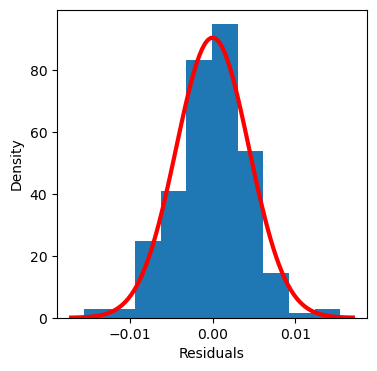

In [216]:
fig = plt.figure(figsize=(4, 4))

plt.hist(pollution_df['residuals'], 
         density=True, 
         bins=10)
plt.xlabel("Residuals")
plt.ylabel("Density")

mean = np.mean(pollution_df['residuals'])
sd = np.std(pollution_df['residuals'])

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

plt.plot(x,
         stats.norm.pdf(x, mean, sd), 
         color='r',
         lw=3)
plt.show()


The histogram shows a slight positive skew, with the right tail stretching out a bit more than the left. Most of the residuals are in that range of -0.01 to 0.01, and the few higher values on the positive side don’t seem large enough to raise any real concern about normality. So it is roughly normal and our assumption is met!

### (E) The residuals have equal/constant variance across all values of X

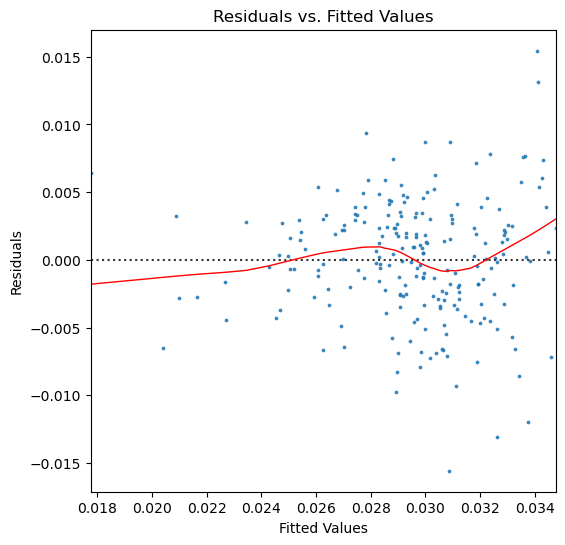

In [219]:
# Residuals vs. Fitted Values Plot
fig = plt.figure(figsize=(6, 6))
sns.residplot(x= pollution_df['fittedvalues'],
              y= pollution_df['residuals'],
              lowess=True,
              scatter_kws={'s': 3},
              line_kws={'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted Values")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()

The residuals vs. fitted values plot shows the residuals spread above and below zero pretty evenly across most of the fitted values. There’s a little variability and a few points that stick out, and you can see a slight funnel shape forming at the higher end, but it goes past our fitted values so we can’t be sure. For now, I’d say the assumption of constant variance (homoscedasticity) is met. Most of our points are spread evenly.

### (A) The model describes all observations (i.e., there are no influential points)

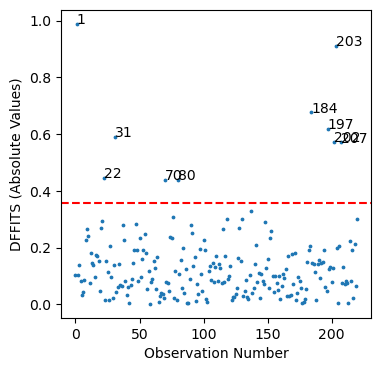

In [222]:
# DFFITS
influence = res_full.get_influence()
pollution_df['dffits'] = influence.dffits[0]  # first element of the tuple contains the DFFITS values

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel("DFFITS (Absolute Values)")
ax.set_xlabel("Observation Number")

ax.scatter(pollution_df.index, np.abs(pollution_df['dffits']), s=3)

cutoff = 2 * np.sqrt(len(res_full.params) / len(pollution_df))
ax.axhline(y=cutoff, color='r', linestyle='dashed')

y_cutoff_label = 0.4
outliers = pollution_df[np.abs(pollution_df['dffits']) > y_cutoff_label]
for i in outliers.index:
    ax.annotate(str(i), (i, np.abs(pollution_df['dffits'][i])))

plt.show()


In [223]:
print(pollution_df.iloc[1])
print('\n',pollution_df.iloc[203])

State                          Alaska
County          Fairbanks North Star 
Address              809 Pioneer Road
CO Mean                      0.374673
NO2 Mean                    11.237066
O3 Mean                      0.015281
SO2 Mean                     5.635377
Region                           West
residuals                   -0.015575
fittedvalues                 0.030855
dffits                      -0.988805
Name: 1, dtype: object

 State                      Utah
County                   Uintah
Address         Seep Ridge Road
CO Mean                1.115023
NO2 Mean               1.267737
O3 Mean                0.041171
SO2 Mean               0.048319
Region                     West
residuals              0.007591
fittedvalues           0.033581
dffits                 0.909678
Name: 203, dtype: object


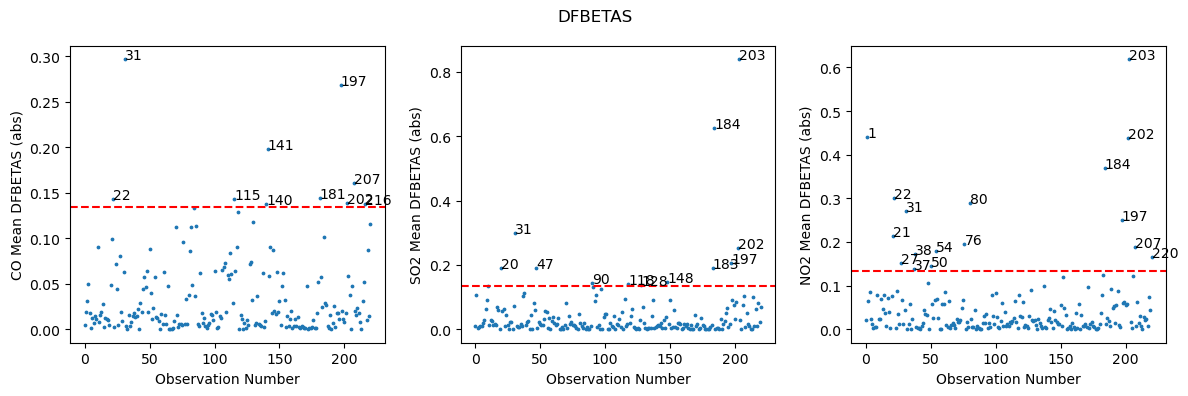

In [224]:
# DFBETAS
df2 = pollution_df[['CO Mean', 'SO2 Mean', 'NO2 Mean']].copy()

def plot_dfbetas(column, ax, label_level=2 / np.sqrt(len(df2))):
    idx = df2.columns.get_loc(column)
    df2['dfbetas_' + column] = res_full.get_influence().dfbetas[:, idx]

    ax.set_ylabel(column + " DFBETAS (abs)")
    ax.set_xlabel("Observation Number")
    ax.scatter(df2.index, np.abs(df2['dfbetas_' + column]), s=3)
    ax.axhline(y=label_level, color='r', linestyle='dashed')

    outliers = df2[np.abs(df2['dfbetas_' + column]) > label_level]
    for i in list(outliers.index):
        ax.annotate(str(i), (i, np.abs(df2['dfbetas_' + column][i])))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plt.suptitle("DFBETAS")
plot_dfbetas("CO Mean", axes[0])
plot_dfbetas("SO2 Mean", axes[1])
plot_dfbetas("NO2 Mean", axes[2])
fig.tight_layout()
plt.show()


Observation 203 in Uintah County and observation 1 in Alaska might be somewhat influential. On the DFFITS chart, they’re close to each other on the y-axis but relatively far from the other points, so it’s worth keeping an eye on them. For now, they don’t violate assumptions. On the DFBETAS charts, observation 203 stands out a little for SO2 Mean and NO2 Mean, but it’s near points like 185 for SO2 and 1 and 202 for NO2, so it’s not completely alone. For CO Mean, 203 isn’t extreme, and observation 1 isn’t an outlier for any predictors. I would say that the assumptions don’t appear to be violated, but 203 and 1 are worth monitoring since they could have a bigger impact in future analyses.

### (R) Are Additional predictor variables not needed?

The assumptions are not fully met. Some predictor variables that could make the model better are weather factors like temperature, humidity, wind speed, and precipitation, since these all affect pollution levels. You could also include things like population density, land use, how close an area is to major roads, or local industrial emissions. These kinds of variables capture environmental and human impacts that the pollutant concentrations by themselves don’t.

### No multicolinearity

In [229]:
pollution_vifs = pd.DataFrame()
pollution_vifs['Feature'] = X.columns[1:]  # skip constant
pollution_vifs['VIF'] = [vif(X, i) 
                         for i in range(1, len(X.columns))]

pollution_vifs

,Feature,VIF
0,NO2 Mean,7.753625
1,SO2 Mean,3.403375
2,Region_Northeast,1.551196
3,Region_South,1.441379
4,Region_West,2.420087


The VIF results show that most predictors are fine, but NO2 Mean has a VIF of about 6.73, which is above the usual cutoff of 5. This means there is moderate multicollinearity, so the assumption is violated. SO2 Mean is a little elevated at 3.16, but the region variables are all low. This suggests that NO2 Mean shares some variance with other predictors, which could make its coefficient less precise even though it is still an important variable in the model.

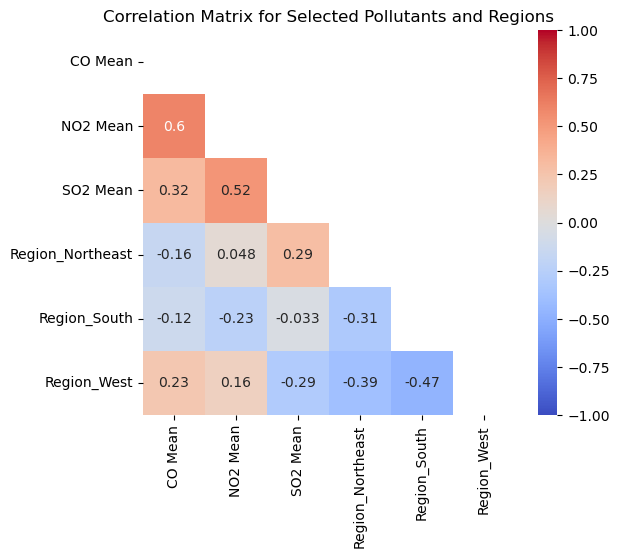

In [231]:
corr_matrix = x_full.iloc[:, 1:].corr()  # skip the constant
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True,
            vmin=-1,
            vmax=1,
            mask=np.triu(corr_matrix))
plt.title("Correlation Matrix for Selected Pollutants and Regions")
plt.show()


The only two correlations that might be a bit of a worry is between NO2 Mean and SO2 Mean, and NO2 and CO Mean which sits at 0.52 and 0.60. That’s a moderate positive relationship, so it’s something to keep an eye on if I include both as predictors in the model. All the other correlations between the region dummies and the pollutants are pretty low, close to zero or slightly negative, so they shouldn’t cause any issues with multicollinearity. Overall, the variables seem fairly independent and safe to use together in the regression. So our assumption is met!

## Variable Selection

### Best Subset Selection Method

In [235]:
y = region_dummy['O3 Mean']

X = region_dummy[['CO Mean', 'NO2 Mean', 'SO2 Mean',
                  'Region_West', 'Region_Northeast', 'Region_South']]
X.head()

,CO Mean,NO2 Mean,SO2 Mean,Region_West,Region_Northeast,Region_South
0,0.243282,8.856462,0.866068,0,0,1
1,0.374673,11.237066,5.635377,1,0,0
2,0.523678,21.091539,1.328253,1,0,0
3,0.584245,22.619903,1.582203,1,0,0
4,0.495108,16.635169,1.328549,1,0,0


In [236]:
feature_groups = [[0], [1], [2], [3, 4, 5]]

In [237]:
best_subsets_selection = EFS(
    estimator=LinearRegression(fit_intercept=True),
    min_features=1,
    max_features=len(feature_groups),  
    scoring='neg_mean_squared_error',
    print_progress=False,
    feature_groups=feature_groups,
    cv=5
)

best_subsets_selection = best_subsets_selection.fit(X, y)
print('Best subset:', best_subsets_selection.best_feature_names_)

Best subset: ('NO2 Mean',)


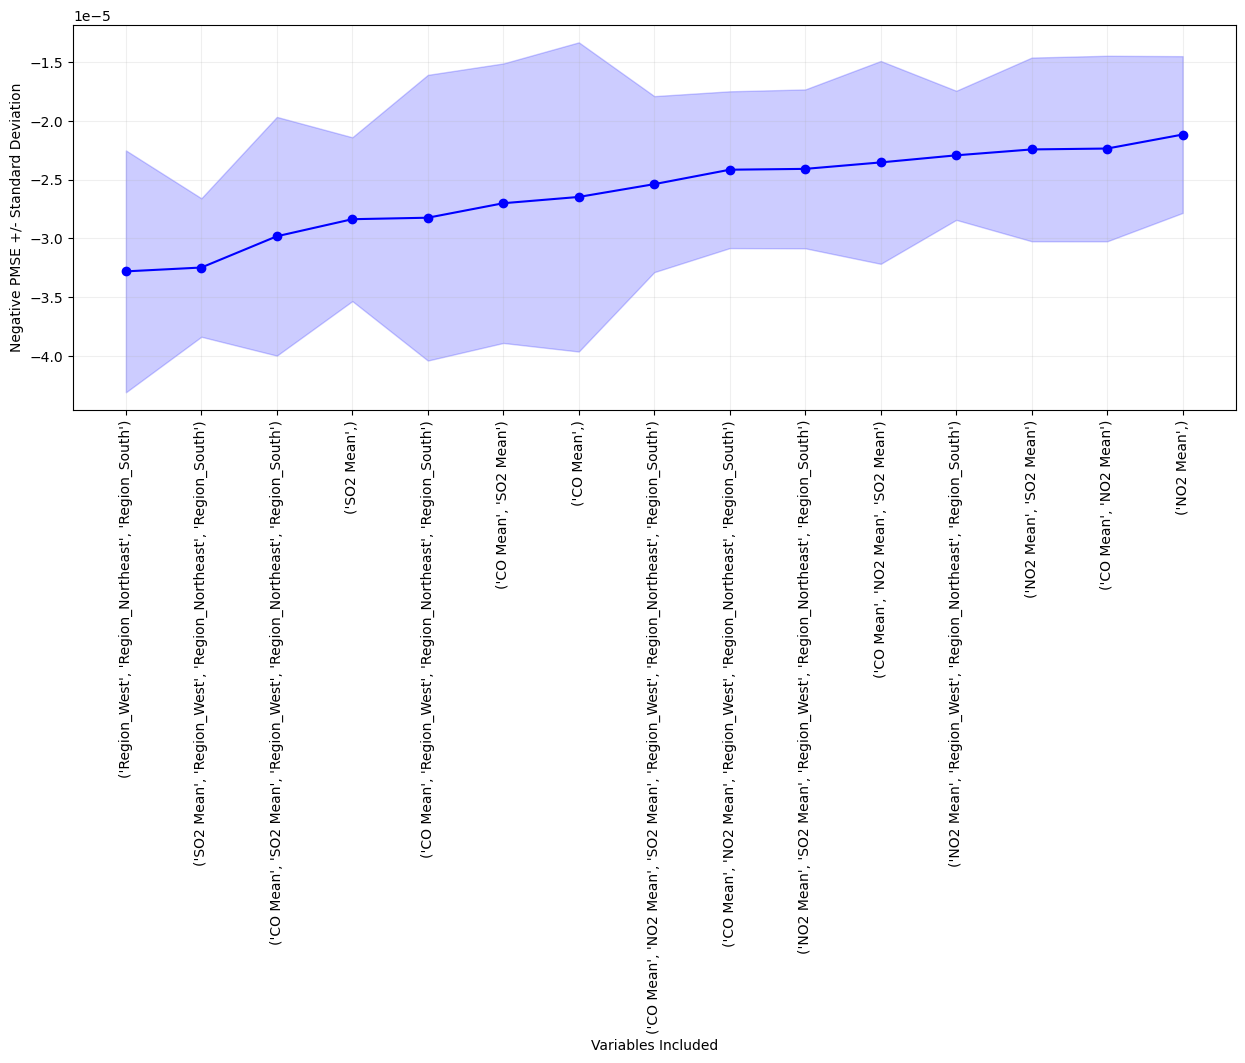

In [238]:
metric_dict = best_subsets_selection.get_metric_dict()
x_axis = sorted(metric_dict.keys())

metric_dict_sorted = dict(sorted(metric_dict.items(), key=lambda x: x[1]['avg_score']))

fig = plt.figure(figsize=(15, 5))
k_feat = metric_dict_sorted.keys()
k_feat_list = list(k_feat)
avg = [metric_dict_sorted[k]['avg_score'] for k in k_feat]

upper, lower = [], []
for k in k_feat:
    upper.append(metric_dict_sorted[k]['avg_score'] + metric_dict_sorted[k]['std_dev'])
    lower.append(metric_dict_sorted[k]['avg_score'] - metric_dict_sorted[k]['std_dev'])

plt.fill_between(
    x_axis,
    upper,
    lower,
    alpha=0.2,
    color='blue',
    lw=1
)

plt.plot(x_axis, avg, color='blue', marker='o')
plt.ylabel('Negative PMSE +/- Standard Deviation')
plt.xlabel('Variables Included')
plt.xticks(
    x_axis, 
    [str(metric_dict_sorted[k]['feature_names']) for k in k_feat_list], 
    rotation=90)
plt.grid(alpha=0.2)
plt.show()

In [239]:
best_subsets_results = pd.DataFrame.from_dict(best_subsets_selection.get_metric_dict()).T
best_subsets_results_sorted = best_subsets_results.sort_values(by='avg_score', ascending=False)
print("\nTop 5 Models:")
display(best_subsets_results_sorted.head(5))


Top 5 Models:


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(1,)","[-2.896783144454615e-05, -2.1700281932169236e-...",-0.000021,"(NO2 Mean,)",0.000009,0.000007,0.000003
4,"(0, 1)","[-2.894053874918993e-05, -2.1699798294820042e-...",-0.000022,"(CO Mean, NO2 Mean)",0.00001,0.000008,0.000004
7,"(1, 2)","[-3.3694078559527996e-05, -2.1918705155056124e...",-0.000022,"(NO2 Mean, SO2 Mean)",0.00001,0.000008,0.000004
8,"(1, 3, 4, 5)","[-2.9218182121509402e-05, -2.3572295432637437e...",-0.000023,"(NO2 Mean, Region_West, Region_Northeast, Regi...",0.000007,0.000005,0.000003
10,"(0, 1, 2)","[-3.380619405391699e-05, -2.191880028780533e-0...",-0.000024,"(CO Mean, NO2 Mean, SO2 Mean)",0.000011,0.000009,0.000004


I ran the best subsets selection, which tested every combination of predictors. The results showed that NO2 Mean alone gave the best performance with the lowest prediction error, making it the strongest predictor of O3 Mean. The next-best models included combinations like CO Mean + NO2 Mean, NO2 Mean + SO2 Mean, and a model with NO2 Mean plus all the Region dummies. Since the analysis requires at least one categorical variable, I will probably be focusing on the model that included NO2 Mean and the Region dummies. Adding the regions slightly increased the CV scores, meaning the fit got a little worse, but the performance stayed very close to the best model. NO2 basically carries all the prediction power.

### Shrinkage Method (LASSO)

In [242]:
# Standardize predictors
X = region_dummy[['CO Mean', 'NO2 Mean', 'SO2 Mean',
                  'Region_Northeast', 'Region_South', 'Region_West']]
y = pollution_df['O3 Mean'].ravel()
variable_names = X.columns
scaler = StandardScaler().fit(X[variable_names])
X[variable_names] = scaler.transform(X[variable_names])

# Create a list of possible alphas
potential_alphas = np.logspace(-4, 2, 500)
LASSOCV_model = LassoCV(alphas=potential_alphas,
                        cv=5, 
                        random_state=12345, 
                        max_iter=10000, 
                        fit_intercept=True)

# Fit the model
LASSOCV_model.fit(X, y)

# Get the list of alphas and corresponding MSEs
alphas = LASSOCV_model.alphas_
pmse_means = np.mean(LASSOCV_model.mse_path_, axis=1)
pmse_std_error = np.std(LASSOCV_model.mse_path_,
                        axis=1, 
                        ddof=1) / np.sqrt(5)

# Find the alpha that minimizes MSE
alpha_index_min = np.argmin(pmse_means)
alpha_min = alphas[alpha_index_min]

# Find the MSE that is one standard error away from the minimum MSE
one_se_above_min = min(pmse_means) + pmse_std_error[alpha_index_min]

# Find the largetst alpha with MSE less than or equal to one_se_above_min
alpha_index_1se = np.where(pmse_means <= one_se_above_min)[0][0]
alpha_1se = alphas[alpha_index_1se]

print("Minimum alpha:", alpha_min)
print("One SE alpha:", alpha_1se)

Minimum alpha: 0.000675552831533164
One SE alpha: 0.0020446606665791177


In [243]:
LASSO_1se = Lasso(alpha=alpha_1se, 
                  fit_intercept=True)
LASSO_1se.fit(X, y)

print(list(zip(LASSO_1se.coef_, X)))

[(-0.0, 'CO Mean'), (-0.000778580281666061, 'NO2 Mean'), (-0.0, 'SO2 Mean'), (-0.0, 'Region_Northeast'), (0.0, 'Region_South'), (-0.0, 'Region_West')]


In [244]:
LASSO_min = Lasso(alpha=alpha_min, 
                  fit_intercept=True)
LASSO_min.fit(X, y)
print(list(zip(LASSO_min.coef_, X)))

[(-0.0, 'CO Mean'), (-0.002147688116712014, 'NO2 Mean'), (-0.0, 'SO2 Mean'), (-0.0, 'Region_Northeast'), (0.0, 'Region_South'), (0.0, 'Region_West')]


The LASSO results show that NO2 Mean is the only predictor that really matters for O3 Mean. Both the minimum alpha and one-standard-error alpha models dropped all the other variables, including CO Mean, SO2 Mean, and the Region categories. This means LASSO determined that once NO2 is included, the other predictors don’t really improve the model. This matches what we saw in the best subsets selection, where NO2 Mean was the strongest predictor. Even though LASSO drops all the categorical variables, for this assignment we will still use the next-best model that keeps Regions to satisfy the requirement of including at least one categorical predictor.

## New Model Fitting and Assumptions Check

### Model Fitting

In [248]:
X_New = region_dummy[['NO2 Mean', 'Region_South', 'Region_Northeast', 'Region_West']]
y_New = pollution_df['O3 Mean']

X_New_const = sm.add_constant(X_New)

model_New = sm.OLS(y_New, X_New_const)
res_New = model_New.fit()

pollution_df['residuals_New'] = res_New.resid
pollution_df['fitted_New'] = res_New.fittedvalues

res_New.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                O3 Mean   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     22.46
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.60e-15
Time:                        20:19:46   Log-Likelihood:                 884.82
No. Observations:                 221   AIC:                            -1760.
Df Residuals:                     216   BIC:                            -1743.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0342      0.001     36.246      0.000       0.032       0.036
NO2 Mean            -0.0004   4.78e-05     -9.153      0.000      -0.001      -0.000
Region_South         0.0003      0.001      0.300      0.764      -0.002       0.002
Region_Northeast    -0.0004      0.001     -0.403      0.688      -0.002       0.002
Region_West          0.0006      0.001      0.637      0.525      -0.001       0.002
==============================================================================
Omnibus:                        4.847   Durbin-Watson:                   1.335
Prob(Omnibus):                  0.089   Jarque-Bera (JB):                6.183
Skew:                          -0.111   Prob(JB):                       0.0454
Kurtosis:                       3.789   Cond. No.                         71.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### (L) X vs Y linear (Three diagonostic tool)

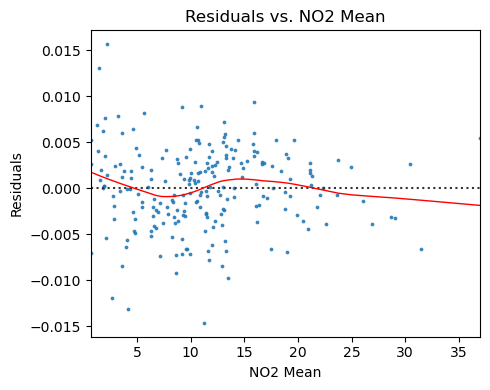

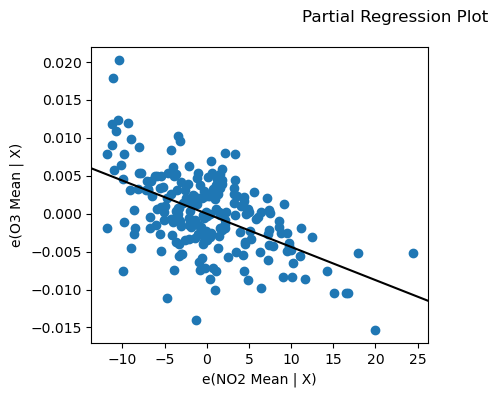

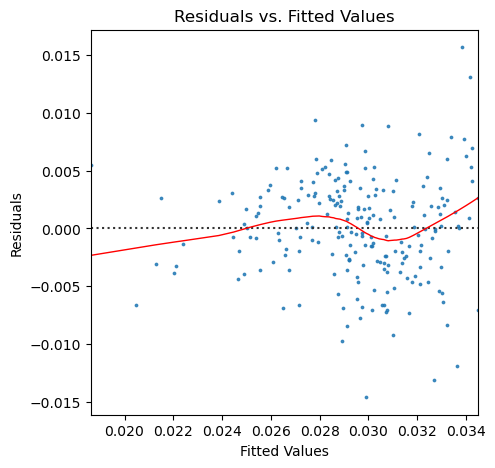

In [250]:
# residual vs. predictor plot (single variable)
def res_vs_pred(variable):
    plt.figure(figsize=(5, 4))
    sns.residplot(x=pollution_df[variable],
                  y=pollution_df['residuals_New'],
                  lowess=True,
                  scatter_kws={'s': 3},
                  line_kws={'color': 'red', 'lw': 1})
    plt.xlabel(variable)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs. {variable}")
    plt.tight_layout()
    plt.show()

# plot for NO2 Mean
res_vs_pred("NO2 Mean")


# Partial Regression Plots
fig = plt.figure(figsize=(8, 4))
sm.graphics.plot_partregress_grid(res_New,
                                  exog_idx=['NO2 Mean'],
                                  grid=(1, 2),
                                  fig=fig)
fig.tight_layout()
plt.show()

#Residuals vs. Fitted Values Plot
fig = plt.figure(figsize=(5, 5))
sns.residplot(x = pollution_df['fitted_New'],
              y = pollution_df['residuals_New'],
              lowess = True,
              scatter_kws = {'s': 3},
              line_kws = {'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted Values")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()

The residuals vs. NO2 Mean and fitted values plots show that the residuals are scattered pretty evenly around zero, without any clear curve or pattern. This suggests the linearity assumption is holding up for the relationship between NO2 Mean and O3 Mean in the model. The partial regression plot also shows a clear negative relationship once we account for all the region dummies. There are a few outliers at the edges, but I’d say the assumption is met for linearity.

### (N) The residuals are normally distributed and centered at zero (Four diagnostic tool)

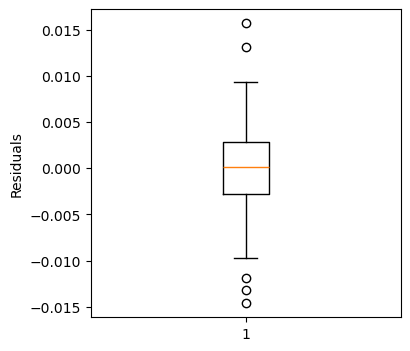

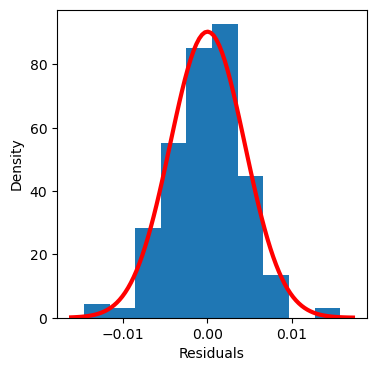

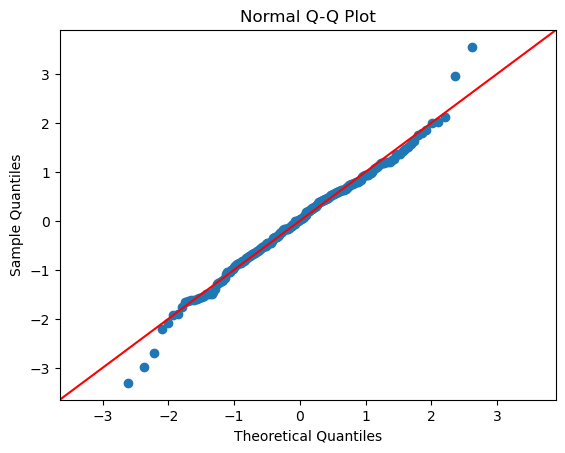


Shapiro-Wilk Test: ShapiroResult(statistic=0.990755988677393, pvalue=0.17239564370697363) 



In [253]:
# Boxplot of residuals
fig = plt.figure(figsize=(4, 4))
plt.boxplot(res_New.resid)
plt.ylabel("Residuals")
plt.show()

# Histogram with normal curve
fig = plt.figure(figsize=(4, 4))
plt.hist(res_New.resid, density=True, bins=10)
plt.xlabel("Residuals")
plt.ylabel("Density")

mean = np.mean(res_New.resid)
sd = np.std(res_New.resid)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, stats.norm.pdf(x, mean, sd), color='r', lw=3)
plt.show()

# Q-Q Plot
sm.qqplot(res_New.resid, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.show()

# Shapiro-Wilk Test for normality
shapiro_test = stats.shapiro(res_New.resid)
print("\nShapiro-Wilk Test:", shapiro_test, '\n')

Looking at the residuals from our updated model predicting O3 Mean using NO2 Mean and the region dummies, they look pretty normal. The boxplot shows most residuals are centered around zero with just a few small outliers. The histogram is fairly symmetric and matches the normal curve well. On the Q-Q plot, most points follow the 45-degree line with only minor deviations at the ends, nothing major. The Shapiro-Wilk test gives a p-value of 0.172, which is above 0.05, so we don’t reject the null. This is pretty similar with what we saw in the full model that also included CO Mean and SO2 Mean.

### (E) The residuals have equal/constant variance across all values of X

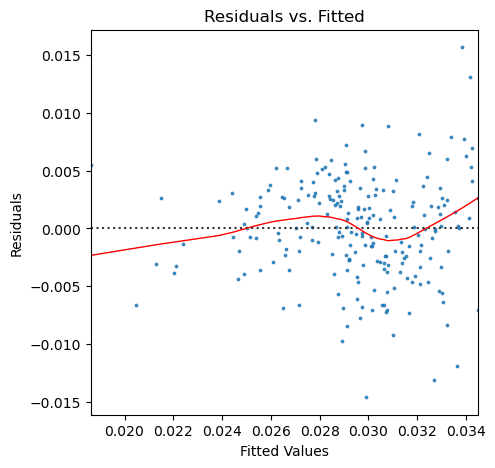

In [256]:
fig = plt.figure(figsize=(5, 5))
sns.residplot(x=res_New.fittedvalues, 
              y=res_New.resid,
              lowess=True,
              scatter_kws={'s': 3},
              line_kws={'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()

For our updated model predicting O3 Mean using NO2 Mean and all the region dummies, the residuals versus fitted plot looks pretty similar to what we saw with the full model. Most points are centered around zero with just a few outliers, actually here it looks like there are less outliers from before! There’s a tiny hint of a funnel shape forming, but it’s hard to tell for sure since it would start stretching past our fitted values. So for now I’d say the homoscedasticity assumption is met.

### (A) The model describes all observations (i.e., there are no influential points)

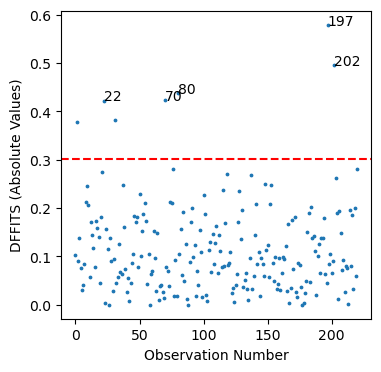

In [259]:
# DFFITS
influence = res_New.get_influence()
pollution_df['dffits_New'] = influence.dffits[0]  # first element of the tuple contains the DFFITS values

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel("DFFITS (Absolute Values)")
ax.set_xlabel("Observation Number")

ax.scatter(pollution_df.index, np.abs(pollution_df['dffits_New']), s=3)

# Use number of parameters from the new model
cutoff = 2 * np.sqrt(len(res_New.params) / len(pollution_df))
ax.axhline(y=cutoff, color='r', linestyle='dashed')

y_cutoff_label = 0.4
outliers = pollution_df[np.abs(pollution_df['dffits_New']) > y_cutoff_label]
for i in outliers.index:
    ax.annotate(str(i), (i, np.abs(pollution_df['dffits_New'][i])))

plt.show()

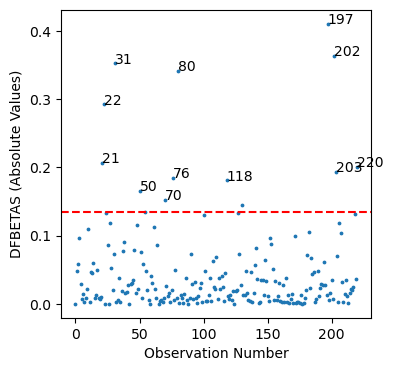

In [260]:
# DFBETAS for NO2 Mean in the new model
region_dummy['dfbetas_NO2'] = res_New.get_influence().dfbetas[:, 1]  # index 1 is NO2 Mean

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel("DFBETAS (Absolute Values)")
ax.set_xlabel("Observation Number")

# scatter + cutoff line
ax.scatter(region_dummy.index, np.abs(region_dummy['dfbetas_NO2']), s=3)
ax.axhline(y=2 / np.sqrt(len(region_dummy)), color='r', linestyle='dashed')

# label potential influential points
y_cutoff_dfbetas = 0.15
outliers_dfbetas = region_dummy[np.abs(region_dummy['dfbetas_NO2']) > y_cutoff_dfbetas]
for i in outliers_dfbetas.index:
    ax.annotate(str(i), (i, np.abs(region_dummy['dfbetas_NO2'][i])))

plt.show()

Awesome! it looks like we don’t have any real outliers. While there are a few points above our cutoff, they’re pretty clustered together and close to the other points. There isn't really a single point that is hevily affecting the model. So I’d confidently say that the assumption is met!

### No Multicolinearity

In [263]:
# Calculate VIF
pollution_vifs = pd.DataFrame()
pollution_vifs['Feature'] = X_New_const.columns[1:]  # skip constant
pollution_vifs['VIF'] = [vif(X_New_const, i) 
                         for i in range(1, len(X_New_const.columns))]

pollution_vifs

,Feature,VIF
0,NO2 Mean,1.058736
1,Region_South,2.051314
2,Region_Northeast,1.850811
3,Region_West,2.151833


The VIF values for NO2 Mean and all the region dummies are all pretty low, around 1 to 2, so there’s no sign of multicollinearity. Each variable is contributing its own info and there’s not much overlap. This looks solid, no worries about multicollinearity here.

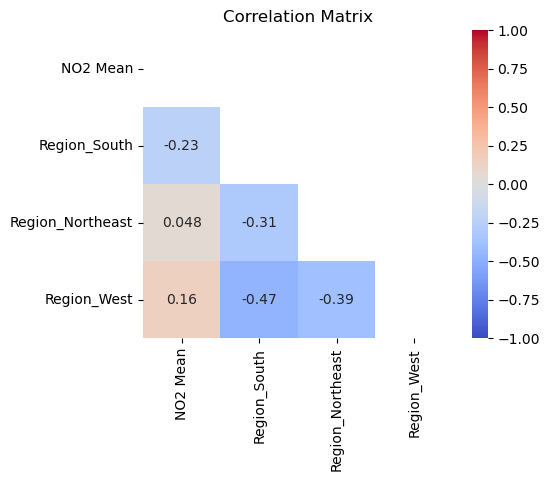

In [265]:
corr_matrix = X_New_const.iloc[:, 1:].corr()

# Plot heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True,
            vmin=-1,
            vmax=1,
            mask=np.triu(corr_matrix))
plt.title("Correlation Matrix")
plt.show()

Looking at the updated matrix there isn’t really a correlation issue. The highest correlation is between NO2 Mean and Region_West at about 0.16, which is really low and nowhere near what would cause multicollinearity. I think the usual cutoff people watch for is around 0.8, so we’re fine here.

## Transformation and its Regression Assumptions

### Model Square Root Transformation

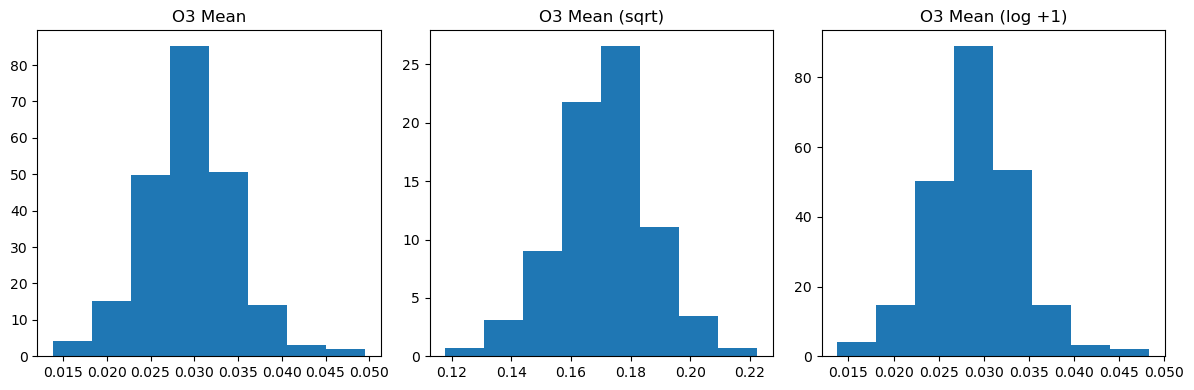

In [269]:
# Square root and log transformations of O3 Mean
O3_sqrt_trans = np.sqrt(pollution_df['O3 Mean'])
O3_log_trans = np.log(pollution_df['O3 Mean'] + 1)

# Function to plot histograms
def hist_Y(variable, bin_size, ax, title):
    ax.hist(variable, density=True, bins=bin_size)
    ax.set_title(title)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
hist_Y(pollution_df['O3 Mean'], 8, axes[0], 'O3 Mean')  
hist_Y(O3_sqrt_trans, 8, axes[1], 'O3 Mean (sqrt)')           
hist_Y(O3_log_trans, 8, axes[2], 'O3 Mean (log +1)')         
fig.tight_layout()
plt.show()

After looking at the residuals and fitted value plots from our updated best-subsets model, all the assumptions seem to be reasonably met. I also checked the distribution of the response variable using the original, sqrt, and log+1 transformations, and none of them look substantially different. The O3 Mean was already roughly normally distributed, and the spread of residuals is fairly even across fitted values, so transforming it barely changes anything Given this, applying a transformation isn’t necessary, and I’m going to stick with the original variable for simplicity and to keep the model easy to interpret and simplier.

## Interaction Effects

### Proposed Interactions

I’m going to include interaction terms between NO2 Mean and all the region dummies (South, Northeast, and West) to see if NO2 has a different effect on O3 depending on the region. The best-subsets results showed that NO2 carries most of the predictive power, but adding the region dummies adjusts for regional differences that might not be explained by NO2. I could see whether NO2 impacts O3 differently in each region and capture any regional variation.

### Model with Interaction Terms

In [275]:
region_dummy['NO2_South'] = region_dummy['NO2 Mean'] * region_dummy['Region_South']
region_dummy['NO2_Northeast'] = region_dummy['NO2 Mean'] * region_dummy['Region_Northeast']
region_dummy['NO2_West'] = region_dummy['NO2 Mean'] * region_dummy['Region_West']

y = pollution_df['O3 Mean']

X_inter = sm.add_constant(region_dummy[['NO2 Mean', 'Region_South', 'Region_Northeast', 'Region_West',
                                       'NO2_South', 'NO2_Northeast', 'NO2_West']])

mod_inter = sm.OLS(y, X_inter)
res_inter = mod_inter.fit()
res_inter.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                O3 Mean   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     12.80
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.07e-13
Time:                        20:19:51   Log-Likelihood:                 885.19
No. Observations:                 221   AIC:                            -1754.
Df Residuals:                     213   BIC:                            -1727.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0338      0.002     21.563      0.000       0.031       0.037
NO2 Mean            -0.0004      0.000     -3.410      0.001      -0.001      -0.000
Region_South         0.0003      0.002      0.166      0.868      -0.004       0.004
Region_Northeast     0.0009      0.002      0.426      0.671      -0.003       0.005
Region_West          0.0009      0.002      0.467      0.641      -0.003       0.005
NO2_South         5.346e-06      0.000      0.030      0.976      -0.000       0.000
NO2_Northeast       -0.0001      0.000     -0.698      0.486      -0.000       0.000
NO2_West         -2.542e-05      0.000     -0.186      0.852      -0.000       0.000
==============================================================================
Omnibus:                        5.066   Durbin-Watson:                   1.329
Prob(Omnibus):                  0.079   Jarque-Bera (JB):                6.681
Skew:                          -0.104   Prob(JB):                       0.0354
Kurtosis:                       3.826   Cond. No.                         165.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

I ran an OLS model including NO2 Mean, the region dummies, and the interactions to see if NO2 affects O3 differently depending on the region. The results show NO2 itself is significant, so higher NO2 still has a clear effect on O3. The region variables and the interaction terms aren’t significant, though, which means the effect of NO2 on O3 doesn’t really change across regions. Basically, NO2 impacts O3 about the same no matter the region, and there’s no strong evidence of any region-specific differences.

In [277]:
anova_lm(res_New, res_inter)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,216.0,0.004309,0.0,NaN,NaN,NaN
1,213.0,0.004294,3.0,0.000014,0.235734,0.871395


I ran an ANOVA to compare the main-effects model with the interaction model to see if adding the NO2 × region terms improves the fit. The results show that the residual sum of squares barely changes, the F-statistic is very small (0.236), and the p-value is high (0.871). This basically confirms what the OLS summary already showed us. Where the interaction terms don’t add any meaningful information, and the effect of NO2 on O3 is pretty consistent across regions. So, we don’t need an interaction model here.

## Model Assessment

In [173]:
pollution_df.head()

,State,County,Address,CO Mean,NO2 Mean,O3 Mean,SO2 Mean,Region,residuals,fittedvalues,dfbetas,residuals_New,fitted_New
0,Alabama,Jefferson,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",0.243282,8.856462,0.027123,0.866068,South,-0.003391,0.030514,0.011741,-0.003515,0.030637
1,Alaska,Fairbanks North Star,809 Pioneer Road,0.374673,11.237066,0.015281,5.635377,West,-0.015575,0.030855,0.105861,-0.014604,0.029885
2,Arizona,Maricopa,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,0.523678,21.091539,0.028326,1.328253,West,0.002955,0.025371,-0.003208,0.002755,0.025571
3,Arizona,Maricopa,2857 N MILLER RD-S SCOTTSDALE STN,0.584245,22.619903,0.020987,1.582203,West,-0.003690,0.024677,-0.007587,-0.003915,0.024902
4,Arizona,Maricopa,4530 N 17TH AVENUE,0.495108,16.635169,0.030383,1.328549,West,0.002965,0.027418,0.009674,0.002861,0.027522


### $R^2$

In [327]:
round(res_New.rsquared, 4)

0.2937

The R-squared is about 0.294, so roughly 29.4% of the variation in O3 Mean is explained by NO2 Mean and the region variables in our model. This leaves over 69.6% of the variation unexplained, coming from other factors or just random noise in ozone measurements. While the model does pick up a real relationship between NO2 and O3, there are plenty of other influences, like weather, season, or other pollutants, that we’re not capturing, which to me seems reasonable on why it is so low.

### Overall Model F-Test and p-value

In [329]:
print("The test statistic for the F-test is ",
      round(res_New.fvalue, 2), 
      " and the corresponding p-value is ", 
      res_New.f_pvalue)

The test statistic for the F-test is  22.46  and the corresponding p-value is  1.5981043120245219e-15


The F-test for the overall model gave a statistic of 22.46 and a p-value of 1.60e-15. That p-value is tiny, which tells us the model is statistically significant. Basically, at least one of the predictors is explaining a meaningful part of the variation in O3 Mean. Most likely my NO2 mean.

### Root Mean Squared Error (RMSE)

In [333]:
pollution_df['O3 Mean'].min(), pollution_df['O3 Mean'].max()

(0.01386379432624113, 0.049524846153846155)

In [335]:
rmse = (((pollution_df['O3 Mean'] - pollution_df['fitted_New']) ** 2).sum() / (len(pollution_df) - 2)) ** 0.5
rmse

0.004435523767204947

The RMSE for our OLS model predicting O3 Mean is about 0.0044 ppb. This means that, on average, the model’s predicted ozone values are off by around 0.0044 ppb. Considering that O3 Mean in the dataset ranges from roughly 0.014 to 0.050 ppb, this error is relatively moderate. NO2 Mean and the region variables give the model some predictive power, but a lot of the variation is still unexplained, reflecting other factors like weather, seasonal changes, or other pollutant sources not included in the model.

### Mean Average Error

In [337]:
mae = np.sum(np.abs(pollution_df['O3 Mean'] - pollution_df['fitted_New'])) / (len(pollution_df) - 2)
mae

0.0034950312591920407

Our MAE is about 0.0035 ppb, which means the predicted O3 Mean values are usually off by roughly three and a half thousandths. Looking at the  range of O3 Mean (0.014 to 0.050 ppb), this error is moderate compared to the scale of the variable. Since MAE is in the same units as O3 Mean, it gives a clear sense of the model’s typical prediction error. Overall, the model keeps predictions fairly close to actual values, but there’s still some error left that could be reduced by including other factors affecting ozone levels.

## Model Statistical Inference

### Confidence Interval for Slope

In [365]:
print(res_New.conf_int().loc['NO2 Mean'])

0   -0.000532
1   -0.000343
Name: NO2 Mean, dtype: float64


We are 95% confident that each one-unit increase in NO2 Mean is linked to a decrease in O3 Mean of about 0.00053 to 0.00034 ppb. Because this entire range is below zero, it shows a clear negative relationship between NO2 and ozone levels. This makes sense because areas with higher NO2, usually from traffic or industrial activity, tend to have slightly lower ozone concentrations.

In [359]:
print(res_New.conf_int().loc['Region_South'])

0   -0.001616
1    0.002198
Name: Region_South, dtype: float64


We are 95% confident that O3 Mean in the South is between -0.0016 and 0.0022 ppb different from the Midwest. Since this interval includes zero, there’s no evidence that ozone levels in the South differ from the Midwest. This makes sense since it is what we saw with the interaction model!

In [361]:
print(res_New.conf_int().loc['Region_West'])

0   -0.001217
1    0.002379
Name: Region_West, dtype: float64


We are 95% confident that O3 Mean in the West is between -0.0012 and 0.0024 ppb different from the Midwest. Because zero is within this range, ozone levels in the West are not significantly different from the Midwest. Same thing with the interaction model we saw.

In [363]:
print(res_New.conf_int().loc['Region_Northeast'])

0   -0.002409
1    0.001592
Name: Region_Northeast, dtype: float64


We are 95% confident that O3 Mean in the Northeast is between -0.0024 and 0.0016 ppb different from the Midwest. Since the interval includes zero, there’s no significant difference compared to the Midwest. Same thing with the interaction model we saw.

### Hypothesis Test of Slope

In [384]:
res_New.pvalues

const               8.854265e-94
NO2 Mean            4.298832e-17
Region_South        7.641531e-01
Region_Northeast    6.875886e-01
Region_West         5.250407e-01
dtype: float64

The hypothesis tests for the slopes show that NO₂ Mean has a p-value of roughly 4.30e-17, far below 0.05. This means NO2 is statistically significant in predicting O3 Mean. Basically, higher NO2 is reliably associated with lower ozone levels, and conversely, lower NO2 corresponds to slightly higher ozone concentrations, so changes in NO2 consistently influence O3.

All three region indicators: South, Northeast, and West. They have p-values well above 0.05 (0.76, 0.69, and 0.53). This indicates that, relative to the Midwest baseline, these regions do not show a statistically significant difference in O3 Mean according to this model.

The intercept has a p-value essentially zero, confirming it is significantly different from zero. This makes sense because it represents the expected O3 Mean in the baseline region (Midwest) when NO2 is zero.

### Confidence Invterval for the Mean Response

In [386]:
pred = res_New.get_prediction([1, 5, 0, 0, 1])  # Intercept, NO2=5, Northeast=0, South=0, West=1
ci_mean = pred.summary_frame(alpha=0.05)[['mean_ci_lower', 'mean_ci_upper']]
ci_mean

,mean_ci_lower,mean_ci_upper
0,0.031411,0.03382


We are 95% confident that, for a location in the West with an NO2 level of 5 ppb, the expected O3 Mean lies between approximately 0.0314 and 0.0338 ppb. Since the West is compared to the baseline region, Midwest, this interval represents the expected ozone level for that region given the NO2 concentration. This means that, given this NO2 level, the model predicts ozone concentrations in the West will typically fall within this range. 

### Prediction Interval for a New Observation

In [388]:
pred = res_New.get_prediction([1, 5, 0, 0, 1])
pred_interval = pred.summary_frame(alpha=0.05)[['obs_ci_lower', 'obs_ci_upper']]
pred_interval

,obs_ci_lower,obs_ci_upper
0,0.023731,0.041501


For a new observation in the West with an NO2 level of 5 ppb, we are 95% confident that the actual O3 Mean will fall between approximately 0.0237 and 0.0415 ppb. This interval is wider than the confidence interval for the mean response because it reflects not just uncertainty in estimating the average O3 level, but also the natural variability we might see in a single measurement. Essentially, while the model gives a reasonable estimate of expected O3 concentrations, individual observations could still vary due to factors not included in the model.

## Conclusion

In this analysis, I used the EPA’s Air Quality dataset, which tracks daily pollution levels across the U.S., including readings for ozone, carbon monoxide, sulfur dioxide, and nitrogen dioxide. The main goal was to see how these pollutants relate to each other and whether ozone levels could be predicted by NO2 and regional differences. I focused on mean values of the pollutants to capture general trends and patterns. Ozone is especially important because of its impacts on human health and the environment, so understanding what drives its levels helps identify where air quality might be more of a concern.

The regression results showed that NO2 is a significant predictor of O3, with higher NO2 associated with slightly lower ozone concentrations, which aligns with expectations given traffic and industrial emissions. RMSE and MAE indicate that the model’s predictions are reasonably close to observed values, though the R squared suggested that a substantial portion of variation remains unexplained. I was a bit surprised by the regional results, the confidence intervals for the South, West, and Northeast all included zero, and none of the p-values were significant. This shows that, in this dataset, regional differences don’t strongly influence ozone once NO2 levels are accounted for, highlighting the pollutant’s dominant role over geography.

Overall, this analysis demonstrates that NO2 is the main driver of ozone variation in the U.S., while regional differences are smaller than I initially expected. The model provides an okay starting point for understanding pollution patterns, but we would really need additional factors like weather, season, or other pollutants. These could heavily improve predictions and insights into air quality trends.